# import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import random
import glob
import cv2
import albumentations as A
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import  ImageDataGenerator
from keras.layers import Dense,Flatten
from keras.callbacks import EarlyStopping,ModelCheckpoint
from keras import Model
from sklearn.metrics import classification_report , confusion_matrix

# get images from dataset files

In [2]:
positive = glob.glob('/kaggle/input/preprocessed-ct-scans-for-covid19/Original CT Scans/pCT/*.jpg')
nigative = glob.glob('/kaggle/input/preprocessed-ct-scans-for-covid19/Original CT Scans/nCT/*.jpg')


random.shuffle(positive)
random.shuffle(nigative)

train_positive = positive [:int (len (positive) *0.8)]
test_positive = positive[int (len (positive) *0.8):]

train_nigative =nigative [:int (len (nigative) *0.8)]
test_nigative = nigative[int (len (nigative) *0.8):]


print ('number of train positive CT = {}'.format(len (train_positive)))
print ('number of train nigative CT = {}'.format(len (train_nigative)))

print ('------------------------------------')

print ('number of test positive CT = {}'.format(len (test_positive)))
print ('number of test nigative CT = {}'.format(len (test_nigative)))

number of train positive CT = 3200
number of train nigative CT = 7983
------------------------------------
number of test positive CT = 801
number of test nigative CT = 1996


# plot sample of each catogery

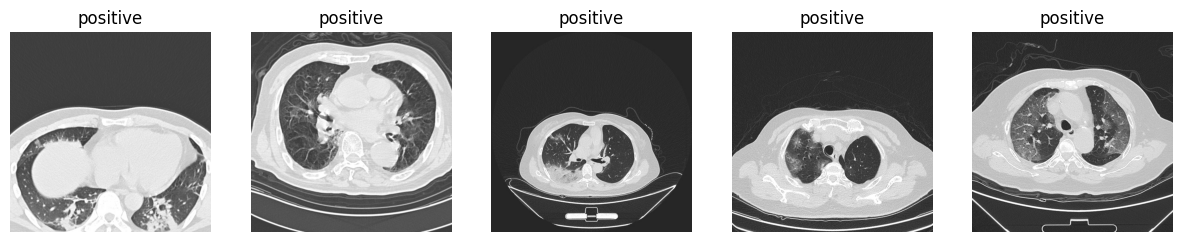

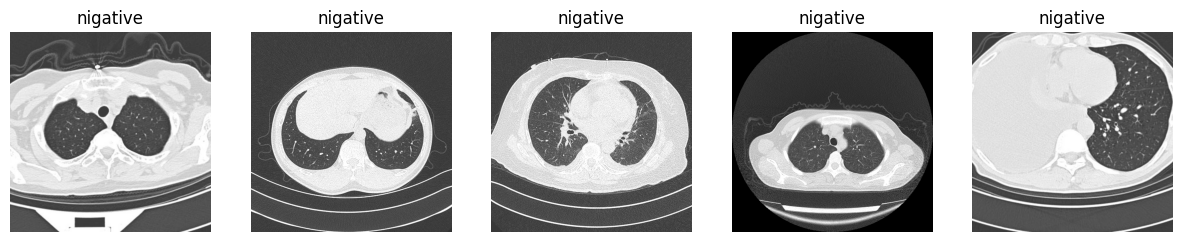

In [8]:
def plot_images (data ,image_title,num_of_images ,type_image = 'bgr'):
    plt.figure(figsize=(15,10))
    for i in range (num_of_images):
        random_image = random.choice(data)
        if type (data) == list:
            random_image = cv2.imread(random_image)
            
        if type_image.lower() == 'bgr':
            random_image =  cv2.cvtColor(random_image, cv2.COLOR_BGR2RGB)
            
        plt.subplot(1,num_of_images,i+1)
        plt.imshow(random_image)
        plt.axis('off')
        plt.title (image_title)
    
    plt.show()
plot_images (train_positive ,'positive',5)
plot_images (train_nigative ,'nigative',5)

# plot categories distribution

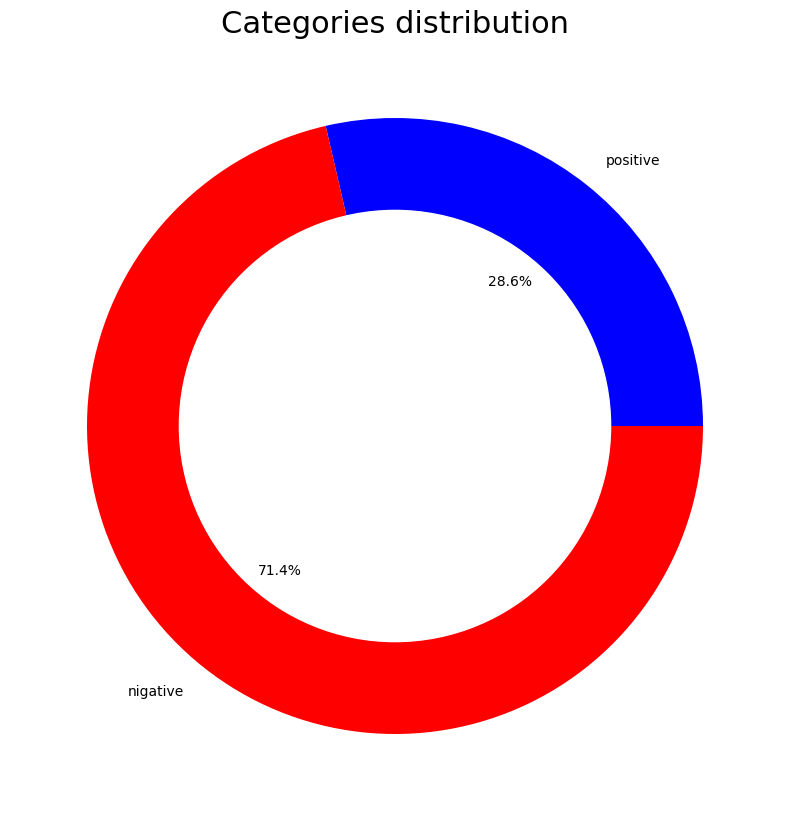

In [10]:
def plt_pie (data,labels,colors,title):
    plt.figure(figsize=(20,10))
    my_circle=plt.Circle( (0,0), 0.7, color='white')
    plt.pie(data,labels = labels, colors = colors , autopct='%1.1f%%')
    p=plt.gcf()
    p.gca().add_artist(my_circle)
    plt.title (title,fontsize = 22)
    plt.show()
    
data = [len (train_positive) , len (train_nigative) ]
labels = ['positive' , 'nigative']
colors = ['blue','red']
plt_pie (data,labels,colors , 'Categories distribution')

# define functions to agumante image

In [4]:
import cv2
import numpy as np

def process_images(low_data, target):
    images = []
    
    while len(images) < target:
        for image_path in low_data:
            img = cv2.imread(image_path)
            if img is None:
                print(f"Warning: Unable to read image {image_path}. Skipping.")
                continue
            
            img = cv2.resize(img, (256, 256))
            
            images.append(img)
            
            if len(images) >= target:
                break
    
    return np.array(images)

# convert link of images to images and resize it

In [5]:
def convert_links_to_images(data):
    images =[]
    for image in data:
        img = cv2.resize(cv2.imread(image), (256, 256) )
        images.append(img)
    return np.array (images)

# apply functions to agumante images and and balncing distribution of images

In [6]:
train_positive_images = process_images(train_positive,3200)
train_negative_images = process_images(train_nigative,7983)
test_positive_images = convert_links_to_images(test_positive)
test_negative_images = convert_links_to_images(test_nigative)  


# plot distribution of train data after balncing

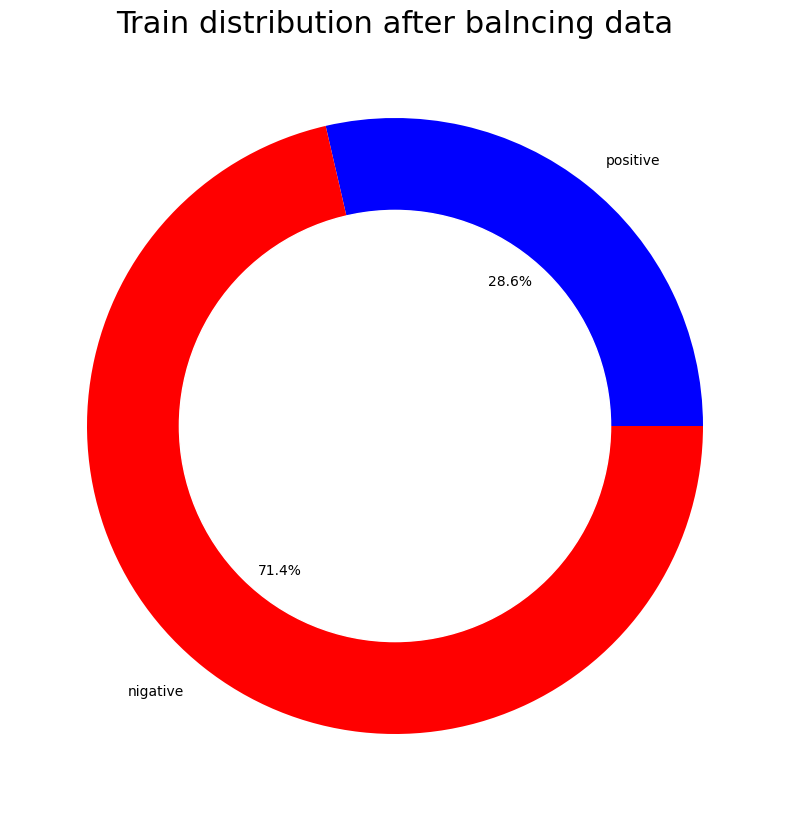

In [11]:
plt_pie ([len (train_positive_images) ,len (train_negative_images)] ,labels,colors,'Train distribution after balncing data')

# plot sample from each category after preprocessing

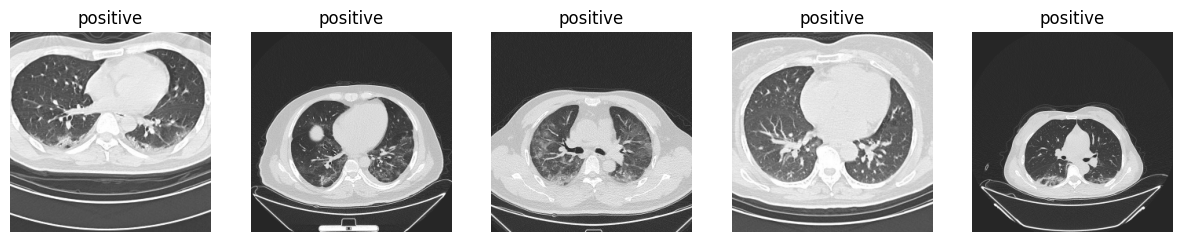

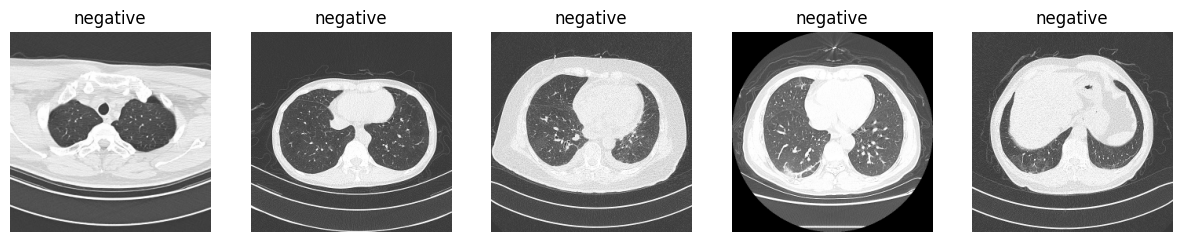

In [12]:
#Train data
plot_images (train_positive_images ,'positive',5)
plot_images (train_negative_images ,'negative',5)

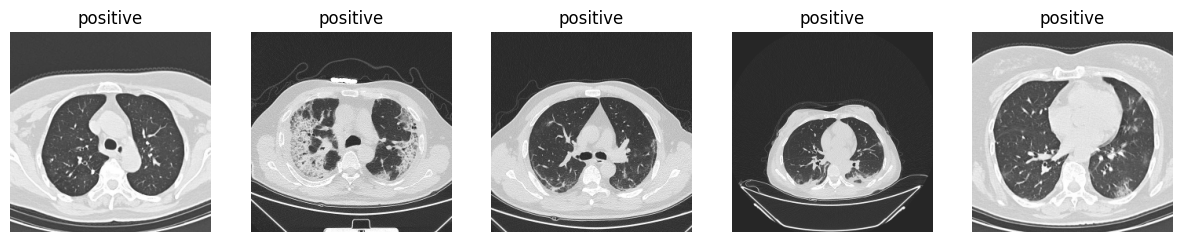

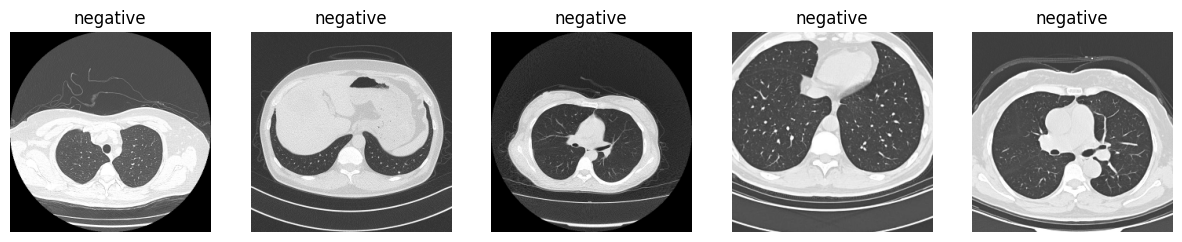

In [13]:
#Test data
plot_images (test_positive_images ,'positive',5)
plot_images (test_negative_images ,'negative',5)

# get train and test data

In [19]:
# Chỉ sử dụng dữ liệu từ hai lớp: positive và negative
y_train = np.concatenate([np.zeros(len(train_positive_images)), np.ones(len(train_negative_images))])
y_train = keras.utils.to_categorical(y_train, num_classes=2)  # Chỉ 2 lớp
X_train = np.concatenate([train_positive_images, train_negative_images], axis=0)

y_test = np.concatenate([np.zeros(len(test_positive_images)), np.ones(len(test_negative_images))])
y_test = keras.utils.to_categorical(y_test, num_classes=2)  # Chỉ 2 lớp
X_test = np.concatenate([test_positive_images, test_negative_images], axis=0)

# In kích thước dữ liệu
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Giải phóng bộ nhớ
train_positive_images, train_negative_images, test_positive_images, test_negative_images = None, None, None, None
del train_positive_images, train_negative_images, test_positive_images, test_negative_images

(11183, 256, 256, 3)
(11183, 2)
(2797, 256, 256, 3)
(2797, 2)


# create image datagenerator for train and test data

In [15]:
train_datagen = ImageDataGenerator( rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True,
                                    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255,)

train_generator = train_datagen.flow(X_train, y_train,batch_size=16,shuffle=True)
test_generator = test_datagen.flow(X_test, y_test,batch_size=16,shuffle=False)
#--------------------------------free some memory--------------------------------
X_train,y_train,X_test = None, None,None
del X_train,y_train,X_test

# get inception_v3 pre trained model

In [20]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

resnet = ResNet50(input_shape=(256, 256, 3),
                  include_top=False,
                  weights=None)

resnet.trainable = False

last_output = resnet.get_layer('conv5_block3_out').output

x = Flatten()(last_output)
x = Dense(32, activation='relu')(x)
x = Dense(2, activation='softmax')(x)

model = Model(inputs=resnet.input, outputs=x)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='model_resnet50.h5', monitor='val_loss', save_best_only=True)
]

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # Thêm label smoothing
              metrics=['accuracy'])

# build full-model and fit model

In [ ]:
history = model.fit(train_generator,
                    epochs=100,
                    validation_data=test_generator,
                    callbacks=callbacks)

model.load_weights('model_resnet50.h5')

Epoch 1/100
699/699 [==============================] - 160s 224ms/step - loss: 0.5844 - accuracy: 0.7198 - val_loss: 0.5480 - val_accuracy: 0.7233
Epoch 2/100
699/699 [==============================] - 159s 227ms/step - loss: 0.5623 - accuracy: 0.7332 - val_loss: 0.5345 - val_accuracy: 0.7419
Epoch 3/100
699/699 [==============================] - 156s 222ms/step - loss: 0.5511 - accuracy: 0.7384 - val_loss: 0.5310 - val_accuracy: 0.7769
Epoch 4/100
699/699 [==============================] - 157s 224ms/step - loss: 0.5458 - accuracy: 0.7428 - val_loss: 0.5128 - val_accuracy: 0.7404
Epoch 5/100
699/699 [==============================] - 157s 224ms/step - loss: 0.5372 - accuracy: 0.7557 - val_loss: 0.4932 - val_accuracy: 0.7969
Epoch 6/100
 73/699 [==>...........................] - ETA: 2:07 - loss: 0.5411 - accuracy: 0.7500

# plot loss and accuracy

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss'] 
tarin_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(range (len (tarin_acc)),tarin_acc,c='b',label = 'training accuracy')
plt.plot (range (len (val_acc)),val_acc,c='r',label = 'validation accuracy')
plt.title ('model accuracy',loc ='right')
plt.legend()
plt.show()

plt.plot(range (len (train_loss)),train_loss,c='b',label = 'training loss')
plt.plot (range (len (val_loss)),val_loss,c='r',label = 'validation loss')
plt.title ('model loss',loc ='right')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ lịch sử huấn luyện
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']  # Sửa lỗi chính tả từ 'tarin_acc' thành 'train_acc'
val_acc = history.history['val_accuracy']

# Vẽ biểu đồ độ chính xác (accuracy)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  # Tạo một subplot với 1 hàng, 2 cột, và chọn subplot thứ nhất
plt.plot(range(len(train_acc)), train_acc, c='b', label='Training Accuracy')
plt.plot(range(len(val_acc)), val_acc, c='r', label='Validation Accuracy')
plt.title('Model Accuracy', loc='center')  # Đặt tiêu đề ở giữa
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')  # Đặt chú thích ở góc dưới bên phải
plt.grid(True)  # Thêm lưới để dễ quan sát

# Vẽ biểu đồ hàm mất mát (loss)
plt.subplot(1, 2, 2)  # Chọn subplot thứ hai
plt.plot(range(len(train_loss)), train_loss, c='b', label='Training Loss')
plt.plot(range(len(val_loss)), val_loss, c='r', label='Validation Loss')
plt.title('Model Loss', loc='center')  # Đặt tiêu đề ở giữa
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')  # Đặt chú thích ở góc trên bên phải
plt.grid(True)  # Thêm lưới để dễ quan sát

plt.tight_layout()  # Tự động điều chỉnh khoảng cách giữa các subplot
plt.show()

# print confusion matrix and classification report

In [ ]:
y_pred = np.round (model.predict (test_generator))
y_pred = np.argmax (y_pred,axis =1)
y_test = np.argmax (y_test,axis =1)
sns.heatmap(confusion_matrix(y_test,y_pred),annot = True,fmt='d')
print (classification_report (y_test,y_pred))

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Dự đoán trên tập kiểm tra
y_pred = model.predict(test_generator)  # Dự đoán xác suất
y_pred = np.argmax(y_pred, axis=1)  # Chuyển đổi xác suất thành nhãn lớp

# Lấy nhãn thực tế từ test_generator
y_test = test_generator.classes  # Lấy nhãn thực tế từ generator

# Tạo confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Vẽ heatmap cho confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_generator.class_indices.keys(), 
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# In báo cáo phân loại
print(classification_report(y_test, y_pred, target_names=test_generator.class_indices.keys()))